Second generation electrostim code because i dont want to lose the progress of the orignal one but new pipeline and it started getting really long

In [1]:
#Packages
import sys
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks, iirnotch
from scipy.optimize import curve_fit
from scipy.ndimage import convolve1d
import pandas as pd
import tkinter as tk
from tkinter import filedialog
import os
sys.path.append( '/Users/Dell/Documents/RESEARCH/tmsi-python-interface-main/tmsi-python-interface-main/TMSiFileFormats/file_readers')
from poly5reader import Poly5Reader


In [ ]:
#Packages (but on desktop)
import sys
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks, iirnotch
from scipy.optimize import curve_fit
from scipy.ndimage import convolve1d
import pandas as pd
import tkinter as tk
from tkinter import filedialog
import os
sys.path.append('/Users/Valie/Documents/Electrostim')
from poly5reader import Poly5Reader


![alt text](<Screenshot 2025-08-05 113746.png>)

In [ ]:
#Grid order (for 8x8 grid)
#Also the view is as if the sticker is ALREADY on the skin, with tails of the sticker pointing towards thumbs
#remember index starts a 0
grid = [
    [17, 16, 15, 14, 13,  9,  5,  1],
    [22, 21, 20, 19, 18, 10,  6,  2],
    [27, 26, 25, 24, 23, 11,  7,  3],
    [32, 31, 30, 29, 28, 12,  8,  4],
    [33, 34, 35, 36, 37, 53, 57, 61],
    [38, 39, 40, 41, 42, 54, 58, 62],
    [43, 44, 45, 46, 47, 55, 59, 63],
    [48, 49, 50, 51, 52, 56, 60, 64],
]

# 2) Build a zero‐based lookup dict: channel → (row_index, col_index)
channel_to_pos = {
    ch: (r_idx, c_idx)
    for r_idx, row in enumerate(grid)
    for c_idx, ch in enumerate(row)
}

# 3) Query at runtime:
try:
    ch = int(input("Enter channel number (1–64): "))
    row, col = channel_to_pos[ch]
    print(f"Channel {ch} is at R/C index: ({row},{col})")
except (ValueError, KeyError):
    print(f"Channel {ch!r} is not in the 8×8 grid.")


REGULAR TRIAL DATA PIPELINE

In [2]:
# Get Data   
folder_path = "G:\\My Drive\\Research\\Data\\electrostim_data\\Doug 6-27"
root = tk.Tk()
root.withdraw()  # Hide the root window

# Select multiple flexion data files
flexion_files = filedialog.askopenfilenames(
    initialdir=folder_path,
    title="Select Flexion Data Files"
)

# Select baseline data (single file)
baseline_data = filedialog.askopenfilename(
    initialdir=folder_path,
    title="Select Baseline file"
 )

# flexion_files will be a tuple of file paths
print("Selected flexion files:", flexion_files)
print("Selected baseline file:", baseline_data)

Selected flexion files: ('G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_9_FLX-20250627_152425.poly5',)
Selected baseline file: G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_2_FLX-20250627_150914.poly5


In [3]:
# Loading in Data
# Loop through each selected flexion file
#72 = trigger channel on recrutiment curve, 73 on regular
#69 = aux channel on recruitment curve data, 70 on regular
# aux [3] = iso aux channel
for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    ch_names = reader.ch_names
    sample_rate = reader.sample_rate
    print(f"Loaded: {file_path}")
    print(reader.ch_names)

    # Extract trigger and EMG data
    trigger_channel = ['TRIGGERS']
    trigger_indices = [ch_names.index(name) for name in trigger_channel if name in ch_names]
    trigger_samples = samples[trigger_indices, :]
    time_axis = np.arange(trigger_samples.shape[1]) / sample_rate

    # # Example: extract EMG channels (adjust indices as needed) and triggers
    # emg = samples[1:65, :]
    # aux = samples[66:71, :]  # Assuming aux channels are from 66 to 72
    # trigger = samples[72,:]

    #This is for when I am using regular trials from the GUI and not recruitment curve data
    emg = samples[1:66, :]
    aux = samples[70:72, :]  # 
    trigger = samples[73,:]
  
    # processing emg, trigger_samples, etc. for each file

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_9_FLX-20250627_152425.poly5
	 Number of samples:  122850 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.
Loaded: G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_9_FLX-20250627_152425.poly5
['CREF', 'R1C1', 'R1C2', 'R1C3', 'R1C4', 'R1C5', 'R1C6', 'R1C7', 'R1C8', 'R2C1', 'R2C2', 'R2C3', 'R2C4', 'R2C5', 'R2C6', 'R2C7', 'R2C8', 'R3C1', 'R3C2', 'R3C3', 'R3C4', 'R3C5', 'R3C6', 'R3C7', 'R3C8', 'R4C1', 'R4C2', 'R4C3', 'R4C4', 'R4C5', 'R4C6', 'R4C7', 'R4C8', 'R5C1', 'R5C2', 'R5C3', 'R5C4', 'R5C5', 'R5C6', 'R5C7', 'R5C8', 'R6C1', 'R6C2', 'R6C3', 'R6C4', 'R6C5', 'R6C6', 'R6C7', 'R6C8', 'R7C1', 'R7C2', 'R7C3', 'R7C4', 'R7C5', 'R7C6', 'R7C7', 'R7C8', 'R8C1', 'R8C2', 'R8C3', 'R8C4', 'R8C5', 'R8C6', 'R8C7', 'R8C8', 'BIP 01', 'BIP 02', 'BIP 03', 'BIP 04', 'ISO aux', 'ISO aux', 'AUX 1-3', 'AUX 2-1', 'TRIGGERS', 'STATUS', 'COUNTER']


In [4]:
# Find first channel named exactly 'Aux'
try:
    aux_index = next(i for i, name in enumerate(ch_names) if name == 'TRIGGERS')
    print(f"First 'Aux' channel found: {ch_names[aux_index]} at index {aux_index}")
except StopIteration:
    print("No channel named 'Aux' found.")


First 'Aux' channel found: TRIGGERS at index 73


In [5]:
#Assign time windows of interest m and h wave
m_window_ms = (6, 10)    # M-wave window in ms
h_window_ms = (25, 35)  # H-wave window in ms
# Convert to sample indices
m_window_samples = (int(m_window_ms[0] * sample_rate / 1000),
                    int(m_window_ms[1] * sample_rate / 1000))
h_window_samples = (int(h_window_ms[0] * sample_rate / 1000),
                    int(h_window_ms[1] * sample_rate / 1000))

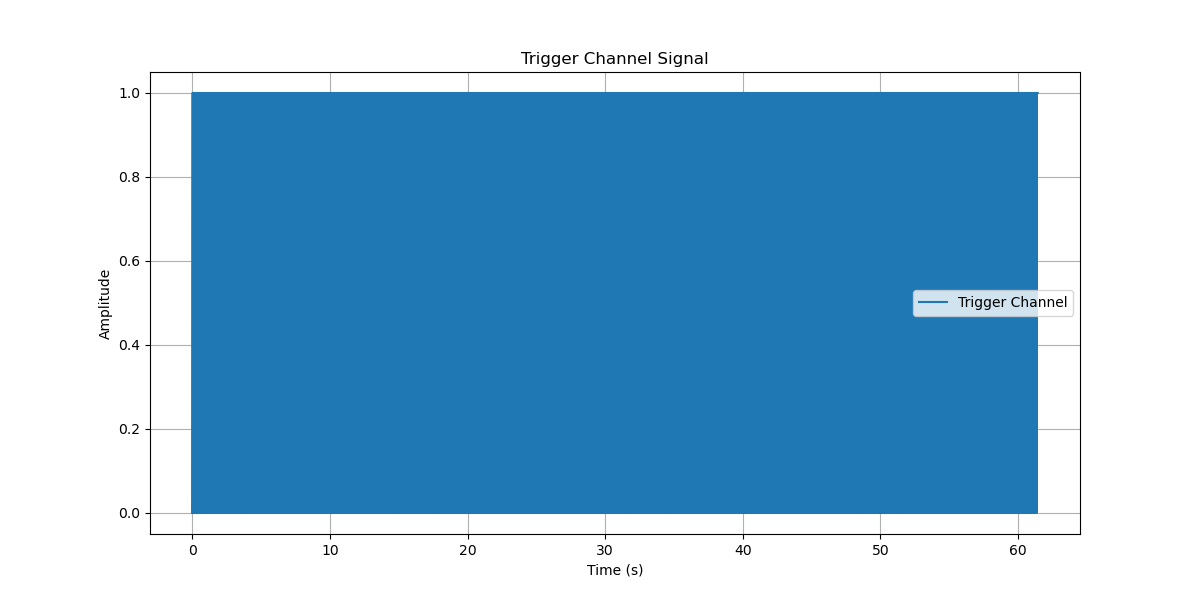

In [6]:
#Plot trigger channel (72 on recruitment, 73 on regular)
%matplotlib ipympl
plt.figure(figsize=(12, 6)) 
plt.plot(time_axis, trigger_samples[0], label='Trigger Channel')
plt.title('Trigger Channel Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_9_FLX-20250627_152425.poly5
	 Number of samples:  122850 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.


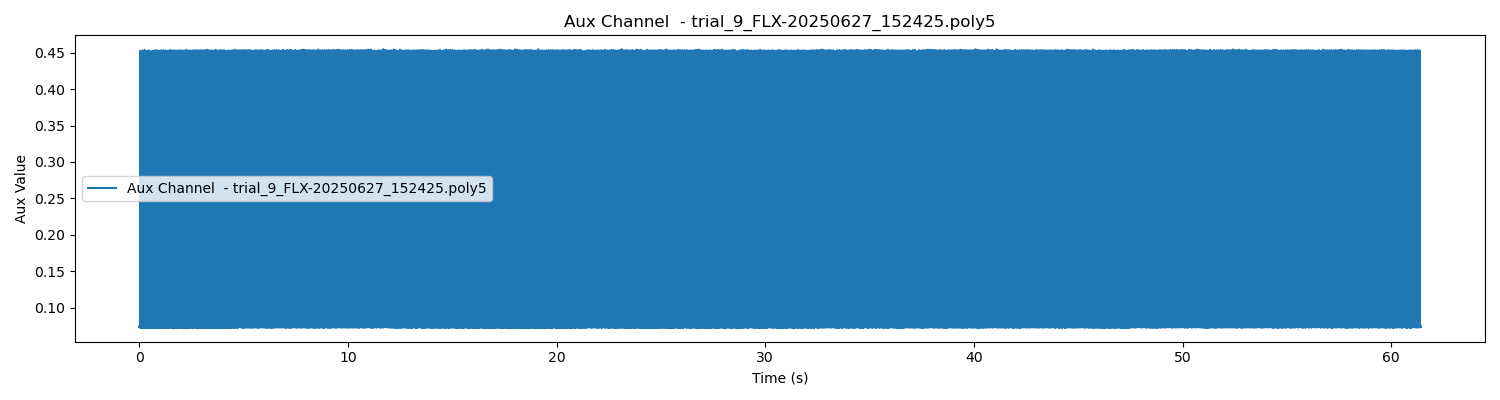

In [7]:
#Plot Aux channel
#Aux channel on recruitment curve = channel 69
#aux channel on regular trial data = channel 70
for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate
    time_axis = np.arange(samples.shape[1]) / sample_rate
    aux = samples[70, :] #nice

    plt.figure(figsize=(15, 4))
    plt.plot(time_axis, aux, label=f"Aux Channel  - {os.path.basename(file_path)}")
    plt.xlabel("Time (s)")
    plt.ylabel("Aux Value")
    plt.title(f"Aux Channel  - {os.path.basename(file_path)}")
    plt.legend()
    plt.tight_layout()
    plt.show()

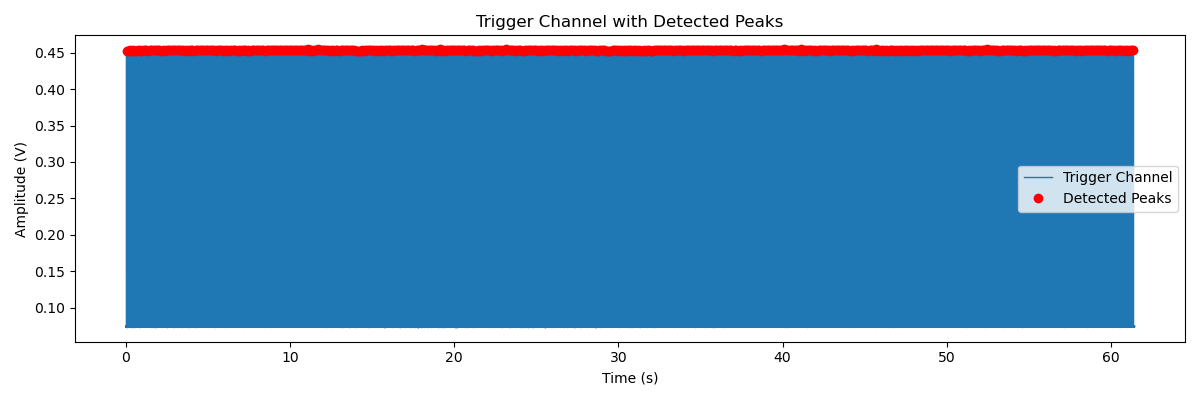

In [8]:
#FIND PEAKS FOR BOTH RECRUITMENT AND TRIAL
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# — your existing variables —
# aux         : 1D numpy array of your analog trigger channel
# sample_rate : sampling frequency in Hz

# 1) Detect peaks
min_height    = 0.2                              # adjust just below your smallest pulse amplitude
min_dist_samps = int(0.005 * sample_rate)        # enforce ≥5 ms between detections
peaks, props  = find_peaks(aux,
                           height=min_height,
                           distance=min_dist_samps)

# 2) Build a time axis
time_axis = np.arange(aux.size) / sample_rate

# 3) Plot the trigger channel and overlay detected peaks
plt.figure(figsize=(12, 4))
plt.plot(time_axis, aux, label='Trigger Channel', linewidth=1)
plt.plot(time_axis[peaks], aux[peaks], 'ro', label='Detected Peaks', markersize=6)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (V)')
plt.title('Trigger Channel with Detected Peaks')
plt.legend()
plt.tight_layout()
plt.show()

array([    99,    300,    500,    700,    902,   1102,   1302,   1503,
         1704,   1905,   2106,   2306,   2507,   2708,   2908,   3108,
         3310,   3510,   3711,   3912,   4112,   4313,   4514,   4714,
         4915,   5116,   5316,   5517,   5718,   5918,   6119,   6320,
         6520,   6721,   6922,   7122,   7323,   7524,   7724,   7925,
         8126,   8326,   8527,   8728,   8928,   9129,   9330,   9530,
         9731,   9932,  10132,  10333,  10534,  10734,  10935,  11136,
        11336,  11537,  11738,  11938,  12139,  12340,  12540,  12741,
        12942,  13143,  13343,  13544,  13745,  13945,  14146,  14347,
        14547,  14748,  14949,  15149,  15350,  15551,  15751,  15952,
        16153,  16353,  16554,  16755,  16955,  17156,  17357,  17557,
        17758,  17959,  18159,  18360,  18561,  18761,  18962,  19163,
        19363,  19564,  19765,  19965,  20166,  20367,  20567,  20768,
        20969,  21169,  21370,  21571,  21771,  21972,  22173,  22373,
      

In [9]:
def butter_highpass(cutoff, fs, order=4):
    nyq = fs / 2.0
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

def highpass_filter(data, cutoff, fs, order=4):
    b, a = butter_highpass(cutoff, fs, order=order)
    return filtfilt(b, a, data, axis=1)  # apply along time axis (axis=1)
    
hp_cutoff = 20 #(Hz)
emg_h = highpass_filter(emg, hp_cutoff, sample_rate, order =4)

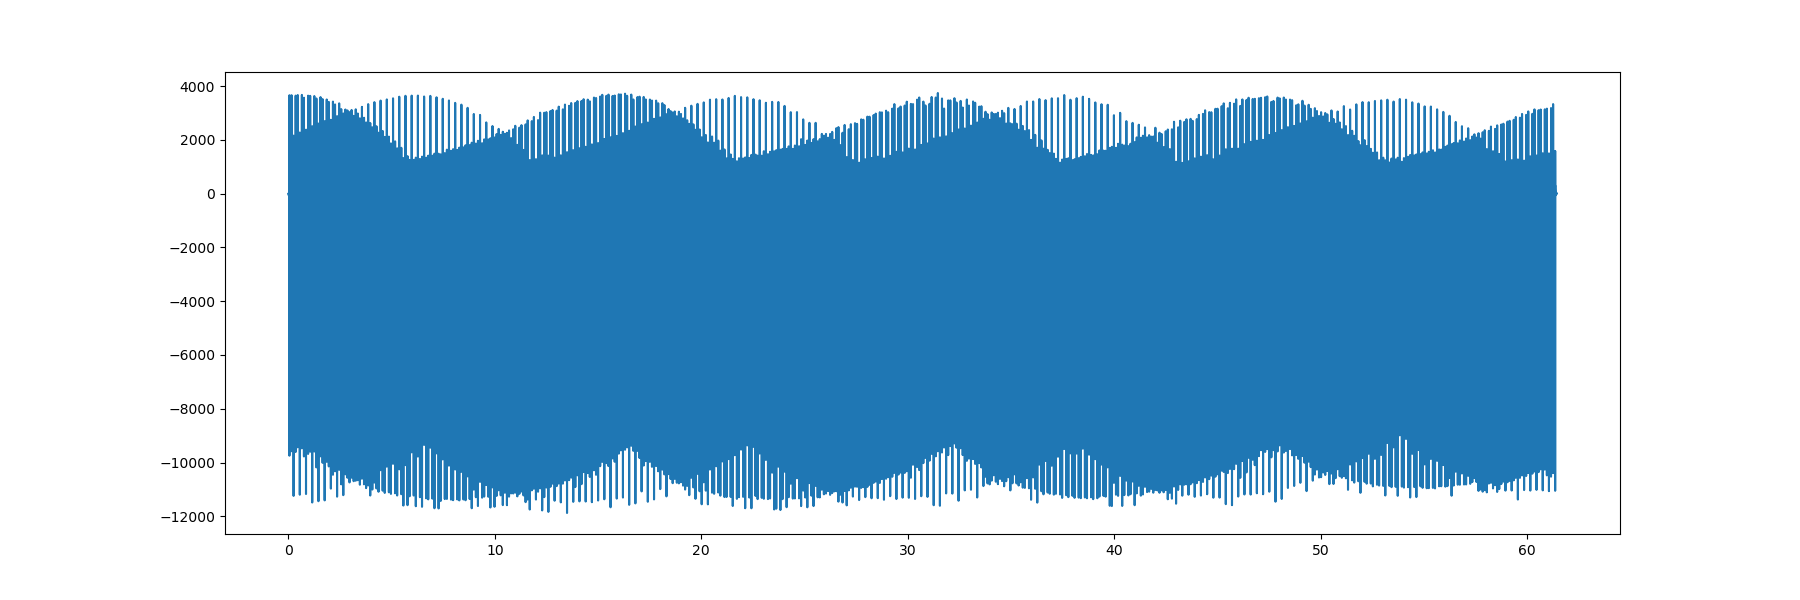

In [10]:
plt.figure(figsize=(18, 6))
plt.plot(time_axis,emg_h[5])

In [ ]:
import numpy as np

# Inputs assumed
# emg          : 2D array, shape (n_channels, n_samples)
# aux          : 1D trigger channel
# sample_rate  : in Hz
# peaks        : 1D array of detected peak indices (from find_peaks) time for the peaks in order to base the segmentation off of
#Do 0-40ms after trigger in order to try and encompass both m and h wave

def extract_segments(emg, peaks, sample_rate, post_ms=50):
    """
    Returns:
      segs           : shape (n_peaks_valid, n_channels, n_samps_window)
      peak_idx_valid : 1D array of sample indices used
      peak_t_valid   : 1D array of times (s) for those peaks
      seg_time       : 1D array of times (s) from 0 to post_ms for each segment sample
    """
    n_ch, n_samps = emg.shape
    win_samps = int(round(post_ms * sample_rate / 1000.0))  # samples in 0–post_ms
    if win_samps <= 0:
        raise ValueError("post_ms must be > 0")

    # Only keep peaks where we can take the full window [peak, peak+win_samps)
    valid = peaks + win_samps <= n_samps
    peak_idx_valid = peaks[valid]
    peak_t_valid   = peak_idx_valid / sample_rate

    # Allocate output (n_peaks_valid, n_channels, win_samps)
    segs = np.empty((peak_idx_valid.size, n_ch, win_samps), dtype=emg.dtype)

    for i, p in enumerate(peak_idx_valid):
        segs[i] = emg[:, p : p + win_samps]

    # Time axis for each segment sample relative to trigger (0 at trigger)
    seg_time = np.arange(win_samps) / sample_rate

    return segs, peak_idx_valid, peak_t_valid, seg_time

# 
segs, peak_idx_valid, peak_t_valid, seg_time = extract_segments(emg, peaks, sample_rate, post_ms=50)

print(f"Segments shape: {segs.shape}  # (n_peaks_valid, n_channels, n_samples_in_40ms)")
print(f"First 5 trigger times (s): {np.round(peak_t_valid[:5], 6)}")


Segments shape: (612, 65, 100)  # (n_peaks_valid, n_channels, n_samples_in_40ms)
First 5 trigger times (s): [0.0495 0.15   0.25   0.35   0.451 ]


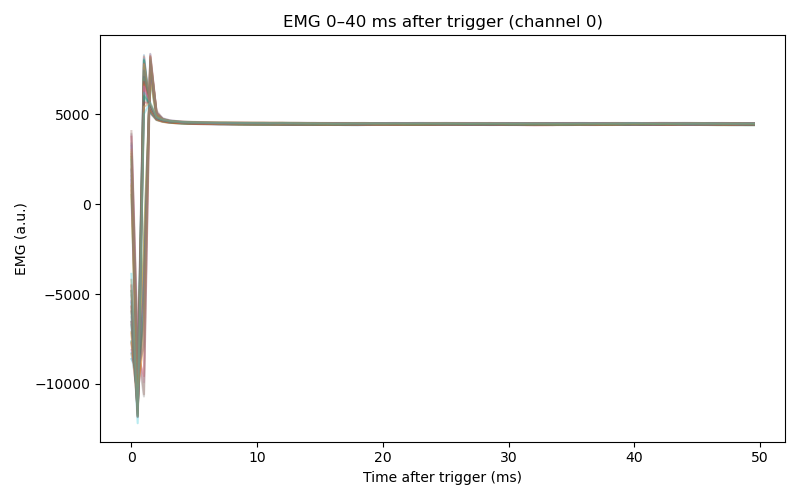

In [12]:
import matplotlib.pyplot as plt

ch = 0  # pick a channel to visualize
plt.figure(figsize=(8,5))
for i in range(min(50, segs.shape[0])):  # overlay up to 50 trials
    plt.plot(seg_time*1000, segs[i, ch], alpha=0.3)
plt.xlabel("Time after trigger (ms)")
plt.ylabel("EMG (a.u.)")
plt.title(f"EMG 0–40 ms after trigger (channel {ch})")
plt.tight_layout()
plt.show()


NEXT STEP = PLOT THE SINGLE AVERAGE OF ALL OF THE 40MS, OVERLAY WITH EACH INDIVIDUAL, THEN BLANK TO GET RID OF STIM ARTIFACT

In [13]:

nrp = np  # alias so we can call nrp.mean as requested

# segs: (n_trials, n_channels, n_samples)
# seg_time: (n_samples,) in seconds, starting at 0 (e.g., from your earlier code)

def mean_at_time_ms(segs, seg_time, ms, window_ms=0.0, return_per_trial=False):
    """
    Average EMG across trials at a specific time after the trigger.

    Args
    ----
    segs : np.ndarray
        Shape (n_trials, n_channels, n_samples), snippets aligned to trigger.
    seg_time : np.ndarray
        Shape (n_samples,), time axis in seconds for each sample in segs.
    ms : float
        Target time in milliseconds after the trigger.
    window_ms : float, default 0.0
        If >0, average within a time window centered at `ms` (width = window_ms).
        If 0, use the nearest single sample.
    return_per_trial : bool, default False
        If True, also return the per-trial values (shape n_trials x n_channels).

    Returns
    -------
    mean_per_channel : np.ndarray
        Shape (n_channels,), average across trials at the selected time/window.
    per_trial (optional) : np.ndarray
        Shape (n_trials, n_channels), the value per trial (already window-averaged).
    indices_used : np.ndarray or int
        Boolean mask (window) or integer index (nearest sample) used along samples.
    """
    if seg_time.ndim != 1:
        raise ValueError("seg_time must be 1D (seconds).")
    if segs.ndim != 3:
        raise ValueError("segs must be (n_trials, n_channels, n_samples).")

    target_s = ms / 1000.0
    if target_s < seg_time[0] or target_s > seg_time[-1]:
        raise ValueError(f"Requested {ms} ms is outside snippet range "
                         f"[{seg_time[0]*1000:.3f}, {seg_time[-1]*1000:.3f}] ms.")

    if window_ms <= 0.0:
        # Nearest single sample
        idx = int(np.argmin(np.abs(seg_time - target_s)))
        per_trial = segs[:, :, idx]                        # (n_trials, n_channels)
        mean_per_channel = nrp.mean(per_trial, axis=0)     # average across trials
        return (mean_per_channel, per_trial, idx) if return_per_trial else (mean_per_channel, idx)
    else:
        # Centered window average
        half = (window_ms / 1000.0) / 2.0
        mask = (seg_time >= target_s - half) & (seg_time <= target_s + half)
        if not np.any(mask):
            # Fallback to nearest sample if the window captures nothing
            idx = int(np.argmin(np.abs(seg_time - target_s)))
            per_trial = segs[:, :, idx]                    # (n_trials, n_channels)
            mean_per_channel = nrp.mean(per_trial, axis=0)
            return (mean_per_channel, per_trial, idx) if return_per_trial else (mean_per_channel, idx)
        # Average within window along samples, then across trials
        per_trial = nrp.mean(segs[:, :, mask], axis=2)     # (n_trials, n_channels)
        mean_per_channel = nrp.mean(per_trial, axis=0)     # (n_channels,)
        return (mean_per_channel, per_trial, mask) if return_per_trial else (mean_per_channel, mask)


def means_at_times_ms(segs, seg_time, ms_list, window_ms=0.0):
    """
    Convenience wrapper for multiple time points.
    Returns array of shape (n_times, n_channels).
    """
    ms_list = np.atleast_1d(ms_list).astype(float)
    out = []
    for m in ms_list:
        mean_ch, _ = mean_at_time_ms(segs, seg_time, m, window_ms=window_ms)
        out.append(mean_ch)
    return np.vstack(out)


In [17]:
print("Mean EMG at 5 ms (M-wave window):")
mean_mwave, per_trial_mwave, idx_mwave = mean_at_time_ms(segs, seg_time, 5, window_ms=4, return_per_trial=True)
print(mean_mwave)

Mean EMG at 5 ms (M-wave window):
[  4588.94455038   4224.28098379   3921.31612807   5150.82689215
  -8510.54615779   4529.64301073   1160.46691636  -6996.71936195
   3820.24147312   2904.61998018   5042.58976769   4789.38129163
   4650.28686621   4536.31745958   1085.06899704  -1386.21966062
  -3907.77834097   3253.21098426   4963.91168031   4105.20162665
   4898.39354875   4670.27956469   -817.01760093  -1657.47825887
  -3673.90544626   2341.13971395  -1645.62537931   3871.61229773
   4176.41688169   4575.16132004  -2613.69291307  -2190.50572633
    932.72711458   4705.10001193   5341.68410224   1737.90910637
   2865.50203459   4847.65450369  -4735.04225955  -3804.29190505
  -1364.66953945   5308.36126155   3533.03177175   3594.03505563
   3625.53915319   1419.23709102   2328.79894669  -1371.04712893
   2024.75551557   4409.43110288   3454.42176702   3427.90063352
   3549.95171082  -4402.55298339  -8366.92350996 -19637.86292133
   -671.65481224   2752.7088733    3649.49789223   3425.